In [1]:
from google.colab import files
uploaded = files.upload()


Saving titanic.csv to titanic.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score

# allow plots to appear in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['font.size'] = 14

In [22]:
# Read in the data.
titanic = pd.read_csv("titanic.csv")

titanic['Sex'] = titanic.Sex.map({'female':0, 'male':1})

# Create a DataFrame of dummy variables for Embarked.
embarked_dummies = pd.get_dummies(titanic.Embarked, prefix='Embarked')
embarked_dummies.drop(embarked_dummies.columns[0], axis=1, inplace=True)

# Concatenate the original DataFrame and the dummy DataFrame.
titanic = pd.concat([titanic, embarked_dummies], axis=1)

# Print the updated DataFrame.
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,False,True


Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



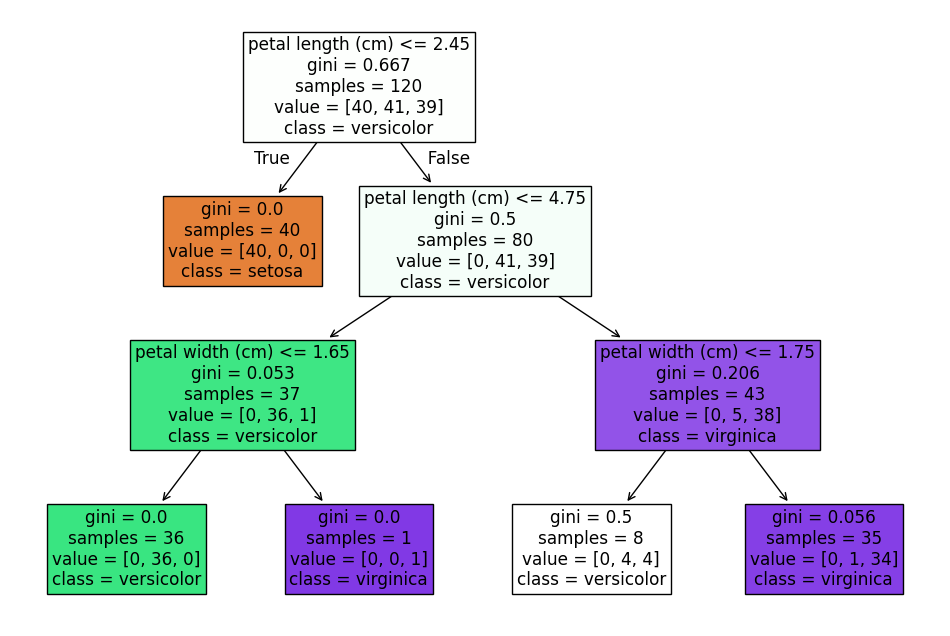

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# 1. Load sample dataset
data = load_iris()
X = data.data
y = data.target

# 2. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize the Decision Tree Classifier
# We set max_depth to prevent overfitting
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 7. Visualize the trained decision tree
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)
plt.show()


Model Accuracy: 79.89 %

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.79      0.90      0.84       105
    Survived       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



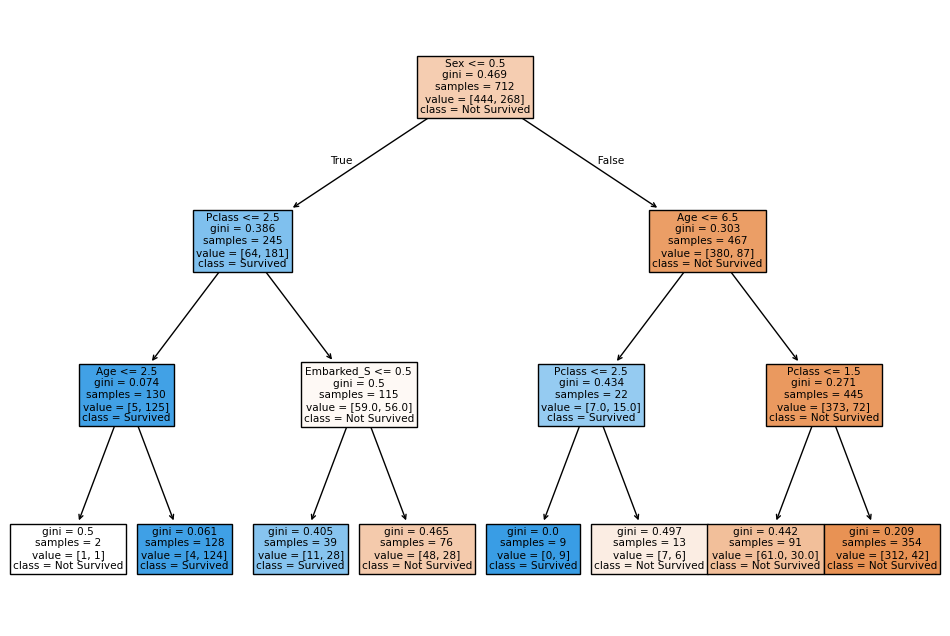

In [23]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd # Import pandas for data manipulation

# Define feature columns that should be used for the model
feature_cols = ['Pclass', 'Sex', 'Age', 'Embarked_Q', 'Embarked_S']

# --- Preprocessing steps to ensure a clean and consistent DataFrame for X and y ---

# 1. Fill missing 'Age' values with the mean, avoiding FutureWarning
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())

# 2. Handle 'Embarked' column for one-hot encoding:
# First, remove any existing dummy columns for 'Embarked' that might have been added incorrectly
# in previous cell executions. This makes the cell idempotent.
columns_to_drop_if_exist = [col for col in ['Embarked_C', 'Embarked_Q', 'Embarked_S'] if col in titanic.columns]
if columns_to_drop_if_exist:
    titanic = titanic.drop(columns=columns_to_drop_if_exist)

# Now, convert 'Embarked' categorical column to numerical using one-hot encoding
# The original 'Embarked' column will be dropped by get_dummies, and new dummy columns added.
titanic = pd.get_dummies(titanic, columns=['Embarked'], prefix='Embarked', dtype=int)

# Ensure 'Embarked_Q' and 'Embarked_S' exist even if no 'Q' or 'S' passengers were in the dataset
# (e.g., if there were only 'C' passengers, get_dummies wouldn't create them)
# This makes the feature selection robust if a specific dummy column is missing from get_dummies output.
for col in ['Embarked_Q', 'Embarked_S']:
    if col not in titanic.columns:
        titanic[col] = 0 # Add the column with all zeros if it's missing

# Now, select the features (X) and target (y) from the processed titanic DataFrame
X = titanic[feature_cols]
y = titanic.Survived

# --- End of Preprocessing ---

# Define feature names and class names for plotting and reporting
titanic_feature_names = feature_cols
titanic_class_names = ['Not Survived', 'Survived'] # Survived column has 0 and 1

# 2. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize the Decision Tree Classifier
# We set max_depth to prevent overfitting
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f} %\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=titanic_class_names))

# 7. Visualize the trained decision tree
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=titanic_feature_names,
    class_names=titanic_class_names,
    filled=True
)
plt.show()